# 模块 1：点迹聚类（`/cluster`）可视化示例

对应 `design/函数接口.md` 模块 1，演示两个函数的**直观效果**：

1. `filter_ground(points, z_thresh)` —— 按高度阈值滤除地面杂波点；
2. `dbscan_cluster(points, eps, min_samples)` —— 官方 `sklearn` DBSCAN 聚类并取质心。

本 notebook 包含 **5 个场景**：

| 场景 | 内容 |
|---|---|
| 1 | 一帧典型雷达点云：原始 → 滤地 → 聚类（3D + 俯视图） |
| 2 | `eps` 参数敏感性：太小 / 合适 / 太大 |
| 3 | 不滤地 vs 滤地：地面杂波被误聚成目标 |
| 4 | 多目标分离（3 个目标 + 强地面杂波） |
| 5 | 开发 / 上机阶段开关演示 |

> 范围说明：本模块只做**纯函数 + 数据类**，不涉及 ROS 节点。
> `sensor_msgs/PointCloud2 → list[Point3D]` 的转换属于节点封装，在后续 `/cluster` 节点中完成。

In [12]:
import os
import sys
import random
import importlib

# 确保可 import 同目录下的 cluster / datatypes
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from datatypes import Point3D
import cluster

print('cluster.STAGE =', cluster.STAGE, '| ONBOARD =', cluster.ONBOARD)
print('numpy', np.__version__)

cluster.STAGE = dev | ONBOARD = False
numpy 2.5.3


## 0. 绘图辅助函数

- `ground(...)`：生成地面杂波（z 在 0 附近高斯抖动）；
- `blob(...)`：生成一个目标点簇（围绕中心均匀抖动）；
- `plot3d / plot2d`：3D / 俯视图散点。

In [14]:
COLORS = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:brown']

# ---------------------------------------------------------------------------
# 统一所有图的坐标范围（三轴一致，便于不同图之间横向对比）
# ---------------------------------------------------------------------------
XLIM = (-35.0, 35.0)
YLIM = (-35.0, 35.0)
ZLIM = (0.0, 15.0)


def set_limits(ax, is3d=True):
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    if is3d:
        ax.set_zlim(*ZLIM)


def xyz(pts):
    return [p.x for p in pts], [p.y for p in pts], [p.z for p in pts]


def ground(n, seed=0, span=30.0, z_std=0.05):
    rng = random.Random(seed)
    return [Point3D(rng.uniform(-span, span), rng.uniform(-span, span), rng.gauss(0.0, z_std))
            for _ in range(n)]


def blob(center, n, spread=0.3, seed=0):
    rng = random.Random(seed)
    return [Point3D(center[0] + rng.uniform(-spread, spread),
                    center[1] + rng.uniform(-spread, spread),
                    center[2] + rng.uniform(-spread, spread))
            for _ in range(n)]


def plot3d(ax, pts, **kw):
    x, y, z = xyz(pts)
    ax.scatter(x, y, z, **kw)


def plot2d(ax, pts, **kw):
    x, y, _ = xyz(pts)
    ax.scatter(x, y, **kw)


## 场景 1：一帧典型雷达点云

构造一帧点云：

- **地面杂波** 200 点，z≈0；
- **目标 A** 中心 `(0, 0, 8)`，10 点；
- **目标 B** 中心 `(12, -6, 6)`，10 点；
- **孤立噪声点** 2 个。

In [13]:
ground_clutter = ground(200, seed=1)
tgt_a = blob((0.0, 0.0, 8.0), 10, spread=0.35, seed=2)
tgt_b = blob((12.0, -6.0, 6.0), 10, spread=0.35, seed=3)
noise = [Point3D(25.0, 20.0, 10.0), Point3D(-28.0, 15.0, 3.0)]

raw = ground_clutter + tgt_a + tgt_b + noise
filtered = cluster.filter_ground(raw, z_thresh=1.0)
clusters = cluster.dbscan_cluster(filtered, eps=1.0, min_samples=3)

print('原始点数       :', len(raw))
print('滤地后点数     :', len(filtered), '(滤掉 z<=1.0 的地面杂波)')
print('聚成簇数       :', len(clusters))
print('被丢弃的噪声点 :', len(filtered) - sum(c.size for c in clusters))
for c in clusters:
    print('  簇 id=%d size=%d centroid=(%.2f, %.2f, %.2f)'
          % (c.id, c.size, c.centroid[0], c.centroid[1], c.centroid[2]))

原始点数       : 222
滤地后点数     : 22 (滤掉 z<=1.0 的地面杂波)
聚成簇数       : 2
被丢弃的噪声点 : 2
  簇 id=0 size=10 centroid=(0.01, 0.06, 7.91)
  簇 id=1 size=10 centroid=(11.89, -5.90, 6.05)


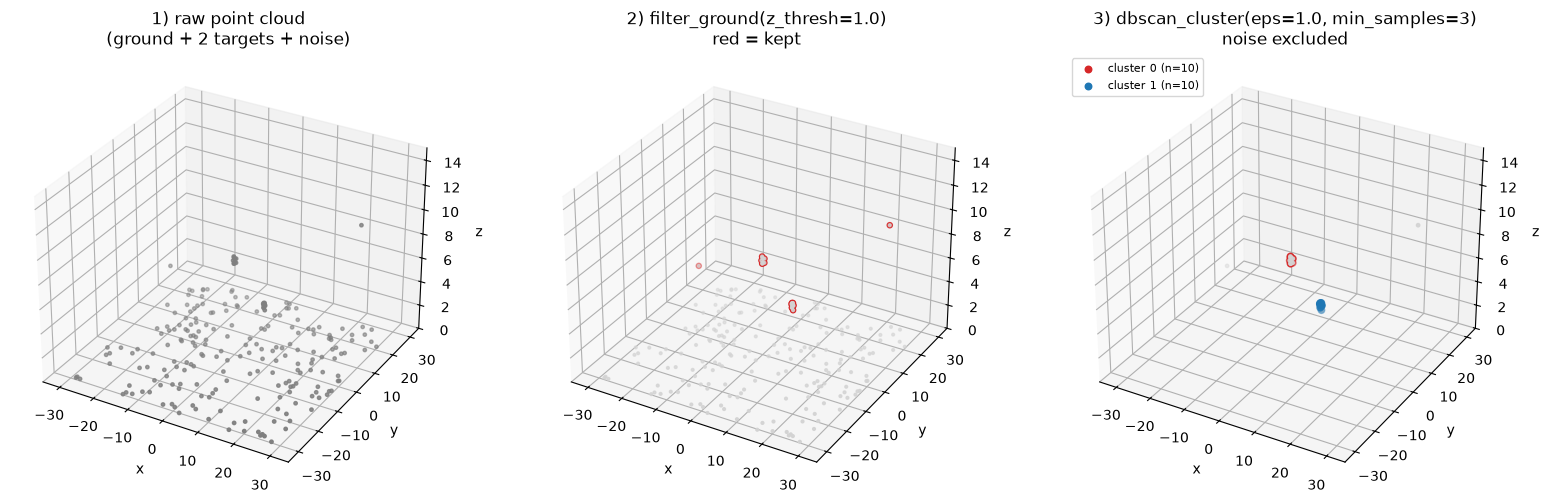

In [15]:
fig = plt.figure(figsize=(16, 5))

ax = fig.add_subplot(131, projection='3d')
plot3d(ax, raw, s=6, c='tab:gray')
ax.set_title('1) raw point cloud\n(ground + 2 targets + noise)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
set_limits(ax)

ax = fig.add_subplot(132, projection='3d')
plot3d(ax, raw, s=4, c='lightgray')
plot3d(ax, filtered, s=14, c='tab:red')
ax.set_title('2) filter_ground(z_thresh=1.0)\nred = kept')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
set_limits(ax)

ax = fig.add_subplot(133, projection='3d')
plot3d(ax, filtered, s=6, c='lightgray')
for i, c in enumerate(clusters):
    plot3d(ax, c.points, s=22, c=COLORS[i % len(COLORS)], label='cluster %d (n=%d)' % (c.id, c.size))
ax.set_title('3) dbscan_cluster(eps=1.0, min_samples=3)\nnoise excluded')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
set_limits(ax)
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


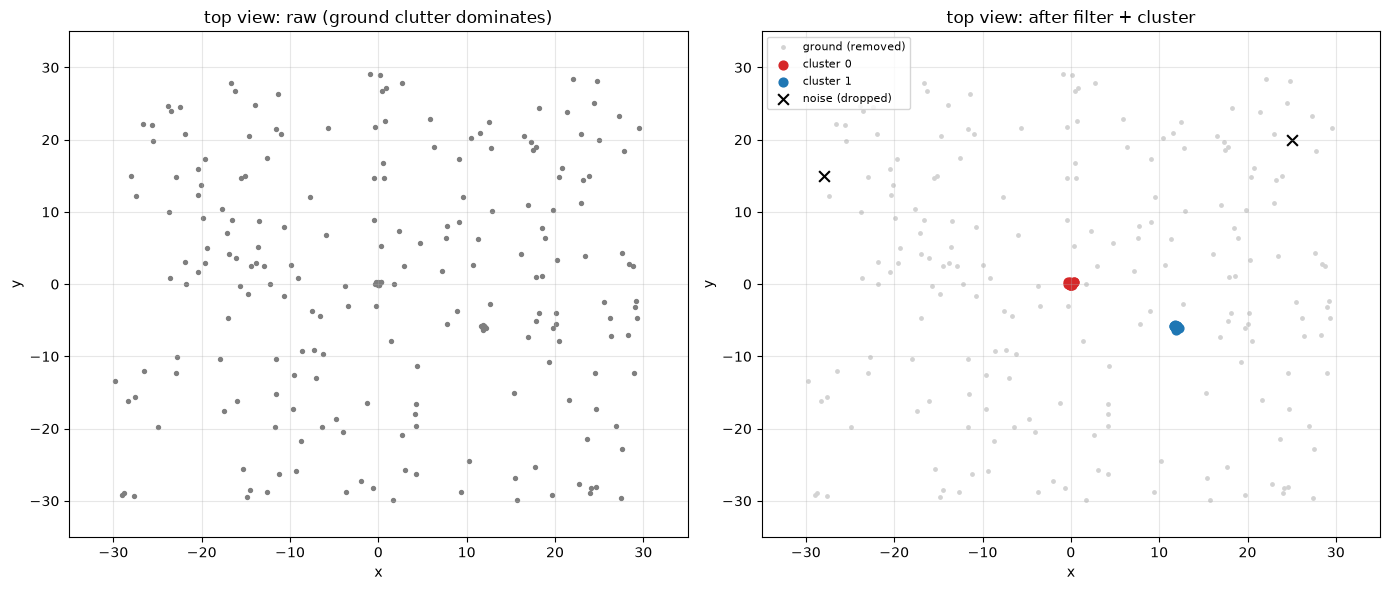

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot2d(axes[0], raw, s=8, c='tab:gray')
axes[0].set_title('top view: raw (ground clutter dominates)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].grid(alpha=0.3)
set_limits(axes[0], is3d=False)

plot2d(axes[1], ground_clutter, s=6, c='lightgray', label='ground (removed)')
for i, c in enumerate(clusters):
    plot2d(axes[1], c.points, s=40, c=COLORS[i % len(COLORS)], label='cluster %d' % c.id)
plot2d(axes[1], noise, s=60, c='black', marker='x', label='noise (dropped)')
axes[1].set_title('top view: after filter + cluster')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].grid(alpha=0.3)
set_limits(axes[1], is3d=False)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 场景 2：`eps` 参数敏感性

同一份滤地点云，仅改变 `eps`：

- `eps` 太小 → 目标点之间互不相邻，全部被判为噪声（0 簇）；
- `eps` 合适 → 两个目标各自成簇；
- `eps` 太大 → 两个目标被连成一个大簇。

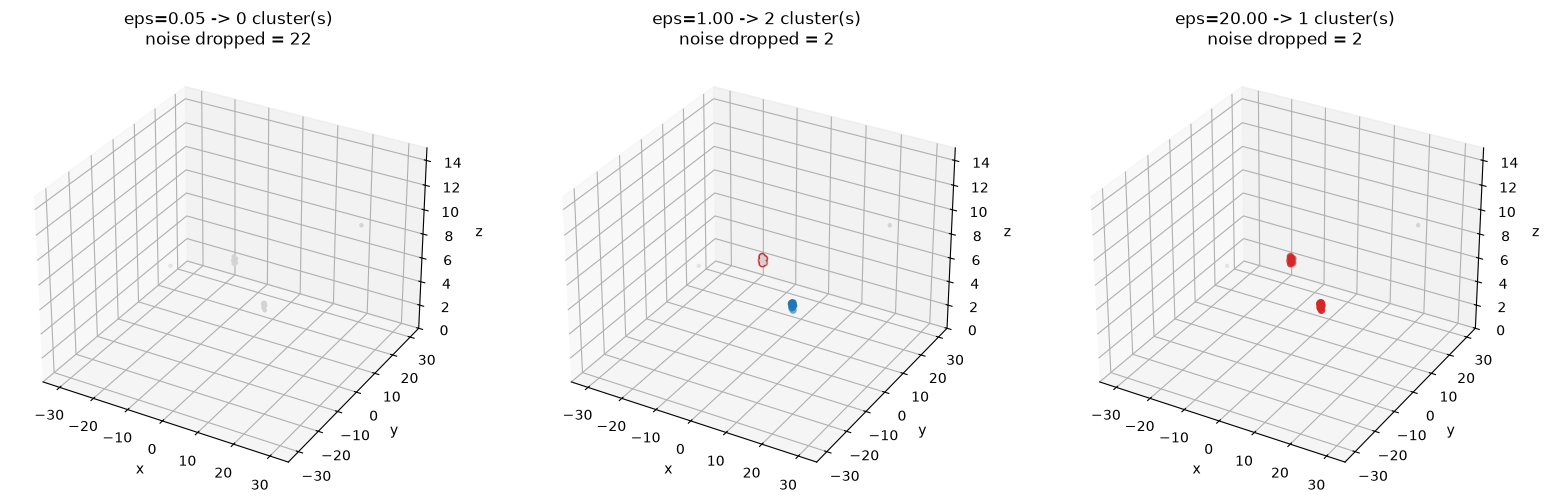

In [19]:
eps_values = [0.05, 1.0, 20.0]

fig = plt.figure(figsize=(16, 5))
for k, eps in enumerate(eps_values):
    cs = cluster.dbscan_cluster(filtered, eps=eps, min_samples=3)
    dropped = len(filtered) - sum(c.size for c in cs)
    ax = fig.add_subplot(1, 3, k + 1, projection='3d')
    plot3d(ax, filtered, s=5, c='lightgray')
    for i, c in enumerate(cs):
        plot3d(ax, c.points, s=20, c=COLORS[i % len(COLORS)])
    ax.set_title('eps=%.2f -> %d cluster(s)\nnoise dropped = %d' % (eps, len(cs), dropped))
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    set_limits(ax)
plt.tight_layout()
plt.show()


## 场景 3：不滤地 vs 滤地

地面杂波是一大片密集点。若**跳过 `filter_ground` 直接聚类**，杂波会被误当成一个大目标；
先滤地后聚类，才能得到干净的 2 个目标簇。

不滤地 -> 12 簇；滤地 -> 2 簇


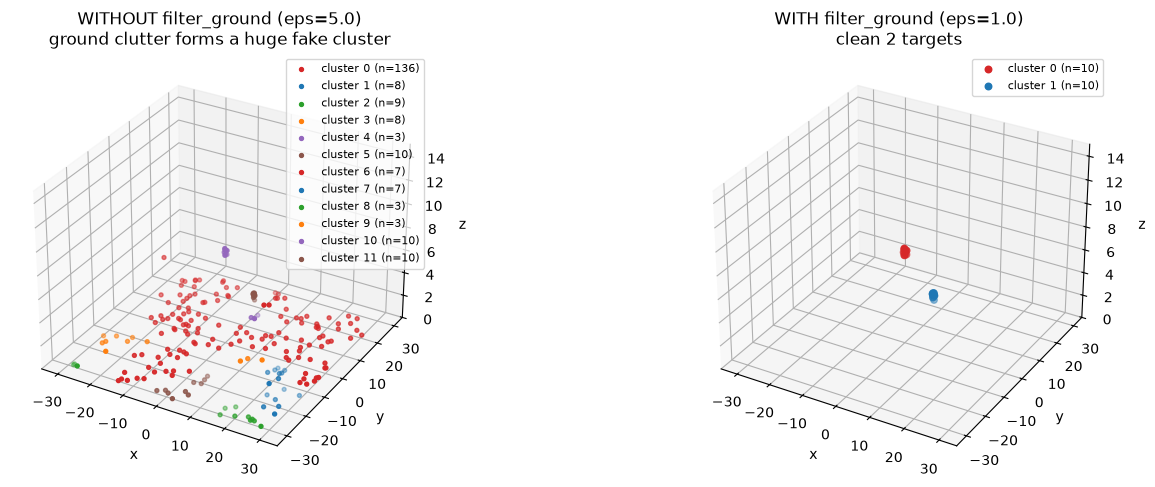

In [17]:
raw_clusters = cluster.dbscan_cluster(raw, eps=5.0, min_samples=3)

fig = plt.figure(figsize=(15, 5))

ax = fig.add_subplot(121, projection='3d')
for i, c in enumerate(raw_clusters):
    plot3d(ax, c.points, s=8, c=COLORS[i % len(COLORS)], label='cluster %d (n=%d)' % (c.id, c.size))
ax.set_title('WITHOUT filter_ground (eps=5.0)\nground clutter forms a huge fake cluster')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
set_limits(ax)
ax.legend(fontsize=8)

ax = fig.add_subplot(122, projection='3d')
for i, c in enumerate(clusters):
    plot3d(ax, c.points, s=22, c=COLORS[i % len(COLORS)], label='cluster %d (n=%d)' % (c.id, c.size))
ax.set_title('WITH filter_ground (eps=1.0)\nclean 2 targets')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
set_limits(ax)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('不滤地 -> %d 簇；滤地 -> %d 簇' % (len(raw_clusters), len(clusters)))


## 场景 4：多目标分离

3 个目标 + 300 点强地面杂波，验证能把多个目标分别聚出来。

multi-target: found 3 clusters (expect 3)
  簇 id=0 size=12 centroid=(0.06, -0.09, 8.00)
  簇 id=1 size=15 centroid=(10.06, 8.06, 4.96)
  簇 id=2 size=9 centroid=(-8.93, 11.99, 7.08)


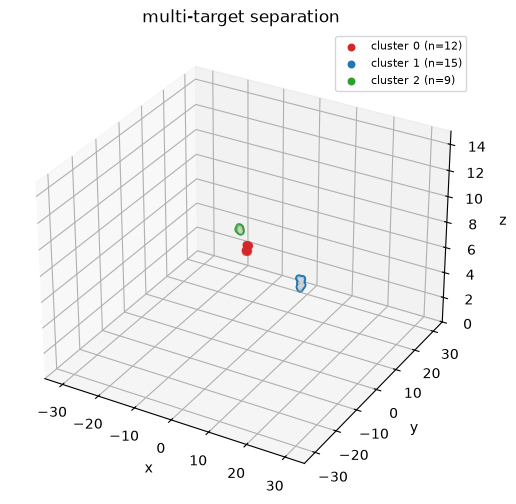

In [18]:
multi = ground(300, seed=7)
multi += blob((0.0, 0.0, 8.0), 12, spread=0.4, seed=4)
multi += blob((10.0, 8.0, 5.0), 15, spread=0.4, seed=5)
multi += blob((-9.0, 12.0, 7.0), 9, spread=0.4, seed=6)

multi_f = cluster.filter_ground(multi, z_thresh=1.0)
multi_c = cluster.dbscan_cluster(multi_f, eps=1.2, min_samples=3)
print('multi-target: found %d clusters (expect 3)' % len(multi_c))
for c in multi_c:
    print('  簇 id=%d size=%d centroid=(%.2f, %.2f, %.2f)'
          % (c.id, c.size, c.centroid[0], c.centroid[1], c.centroid[2]))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
plot3d(ax, multi_f, s=4, c='lightgray')
for i, c in enumerate(multi_c):
    plot3d(ax, c.points, s=22, c=COLORS[i % len(COLORS)], label='cluster %d (n=%d)' % (c.id, c.size))
ax.set_title('multi-target separation')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
set_limits(ax)
ax.legend(fontsize=8)
plt.show()


## 场景 5：开发 / 上机阶段开关

非法参数的处理分阶段（环境变量 `UAV_STAGE`）：

| `UAV_STAGE` | 行为 |
|---|---|
| `dev`（默认） | 直接抛 `ValueError`，问题尽早暴露 |
| `onboard` | 打印告警并返回 `[]`，上机不因脏数据崩溃 |

先看 `dev`（默认）阶段直接报错。

In [20]:
try:
    cluster.dbscan_cluster(filtered, eps=-1.0, min_samples=3)
except ValueError as e:
    print('[dev] ValueError:', e)

[dev] ValueError: [cluster] dbscan_cluster: eps 必须 > 0，实际为 -1.0


In [21]:
import warnings

# 切到上机阶段
os.environ['UAV_STAGE'] = 'onboard'
importlib.reload(cluster)
print('reloaded: STAGE =', cluster.STAGE, '| ONBOARD =', cluster.ONBOARD)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    result = cluster.dbscan_cluster(filtered, eps=-1.0, min_samples=3)
print('result =', result)
for w in caught:
    print('warning:', w.message)

# 恢复默认 dev，避免影响后续使用
os.environ['UAV_STAGE'] = 'dev'
importlib.reload(cluster)
print('restored: STAGE =', cluster.STAGE)

reloaded: STAGE = onboard | ONBOARD = True
result = []
restored: STAGE = dev


## 小结

- `filter_ground` 采用**丢低留高**（保留 `z > z_thresh`），先滤掉地面杂波；
- `dbscan_cluster` 用官方 `sklearn` DBSCAN，**噪声点（label `-1`）不入簇**，其余按簇算质心；
- `eps`/`min_samples` 需按点云密度整定（对应主文档第八章第 4 条：仿真参数不可外推真机）；
- 空输入任何阶段都返回 `[]`（正常业务，非错误）；非法参数按 `UAV_STAGE` 分阶段处理。